# BWV545 real organ vs synth organ check




In [1]:
# =========================
# 1. 基础路径与参数
# =========================

from pathlib import Path
import os
import re
import json
import shutil
import subprocess
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import librosa
import soundfile as sf
import pretty_midi
from scipy.stats import ks_2samp, wasserstein_distance
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from IPython.display import display

# 项目根目录
PROJECT_ROOT = Path(r"D:\organ-amt-generalization")

# 输入路径
REAL_AUDIO_DIR = PROJECT_ROOT / r"data\raw\organ\BWV545\audio"
MIDI_DIR = PROJECT_ROOT / r"data\raw\organ\BWV545\midi"

# 输出路径：按你的要求放在 ex01_data_check 下面
PROCESSED_DIR = PROJECT_ROOT / r"data\processed\ex01_data_check"
BWV545_OUT_DIR = PROCESSED_DIR / "BWV545_real_vs_synth_check"

REAL_WAV_DIR = BWV545_OUT_DIR / "real_wav"
SYNTH_WAV_DIR = BWV545_OUT_DIR / "synth_wav"
FIGURE_DIR = BWV545_OUT_DIR / "figures"
CONFIG_OUT_DIR = BWV545_OUT_DIR / "configs"

for d in [BWV545_OUT_DIR, REAL_WAV_DIR, SYNTH_WAV_DIR, FIGURE_DIR, CONFIG_OUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# 项目中的渲染脚本和原始配置
SYNTH_SCRIPT_PATH = PROJECT_ROOT / r"scripts\organ_bach_synth.py"
BASE_SYNTH_CONFIG_PATH = PROJECT_ROOT / r"configs\data\pre_organ_synth.yaml"

# 如果你的脚本不在 scripts/ 下面，可以手动改这里
# SYNTH_SCRIPT_PATH = PROJECT_ROOT / r"你的路径\organ_bach_synth.py"

# 新生成的 BWV545 专用配置
BWV545_SYNTH_CONFIG_PATH = CONFIG_OUT_DIR / "pre_organ_synth_BWV545.yaml"

# 输出表格
REAL_AUDIO_TABLE_PATH = BWV545_OUT_DIR / "BWV545_real_audio_files.csv"
SYNTH_METADATA_PATH = BWV545_OUT_DIR / "BWV545_synth_metadata.csv"
COMPARE_SAMPLES_PATH = BWV545_OUT_DIR / "BWV545_real_vs_synth_samples.csv"
FEATURE_TABLE_PATH = BWV545_OUT_DIR / "BWV545_real_vs_synth_feature_table.csv"
FEATURE_SUMMARY_PATH = BWV545_OUT_DIR / "BWV545_real_vs_synth_feature_summary.csv"
FEATURE_DISTANCE_PATH = BWV545_OUT_DIR / "BWV545_real_vs_synth_feature_distance.csv"

# 输出图片
CQT_COMPARE_FIG_PATH = FIGURE_DIR / "BWV545_real_vs_synth_cqt_compare.png"
FEATURE_HIST_FIG_PATH = FIGURE_DIR / "BWV545_real_vs_synth_feature_histograms.png"
PCA_FIG_PATH = FIGURE_DIR / "BWV545_real_vs_synth_pca.png"

# 音频参数
TARGET_SR = 44100
FEATURE_DURATION_SEC = 30.0
SEGMENT_START_SEC = 0.0
SEGMENT_DURATION_SEC = 30.0

# CQT 参数
CQT_HOP_LENGTH = 512
CQT_BINS_PER_OCTAVE = 12
CQT_N_BINS = 84
CQT_FMIN = librosa.note_to_hz("A0")

# 图中中文字体
mpl.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "SimSun", "Arial Unicode MS"]
mpl.rcParams["axes.unicode_minus"] = False

print("PROJECT_ROOT:", PROJECT_ROOT)
print("REAL_AUDIO_DIR:", REAL_AUDIO_DIR, "exists:", REAL_AUDIO_DIR.exists())
print("MIDI_DIR:", MIDI_DIR, "exists:", MIDI_DIR.exists())
print("PROCESSED_DIR:", PROCESSED_DIR)
print("BWV545_OUT_DIR:", BWV545_OUT_DIR)
print("SYNTH_SCRIPT_PATH:", SYNTH_SCRIPT_PATH, "exists:", SYNTH_SCRIPT_PATH.exists())
print("BASE_SYNTH_CONFIG_PATH:", BASE_SYNTH_CONFIG_PATH, "exists:", BASE_SYNTH_CONFIG_PATH.exists())

if not REAL_AUDIO_DIR.exists():
    raise FileNotFoundError(f"真实音频目录不存在: {REAL_AUDIO_DIR}")

if not MIDI_DIR.exists():
    raise FileNotFoundError(f"MIDI 目录不存在: {MIDI_DIR}")


PROJECT_ROOT: D:\organ-amt-generalization
REAL_AUDIO_DIR: D:\organ-amt-generalization\data\raw\organ\BWV545\audio exists: True
MIDI_DIR: D:\organ-amt-generalization\data\raw\organ\BWV545\midi exists: True
PROCESSED_DIR: D:\organ-amt-generalization\data\processed\ex01_data_check
BWV545_OUT_DIR: D:\organ-amt-generalization\data\processed\ex01_data_check\BWV545_real_vs_synth_check
SYNTH_SCRIPT_PATH: D:\organ-amt-generalization\scripts\organ_bach_synth.py exists: True
BASE_SYNTH_CONFIG_PATH: D:\organ-amt-generalization\configs\data\pre_organ_synth.yaml exists: True


In [2]:
# =========================
# 2. 检查 FFmpeg 和 FluidSynth
# =========================

# FFmpeg：优先使用 PATH，其次使用你手动下载的位置
FFMPEG_EXE = shutil.which("ffmpeg")
if FFMPEG_EXE is None:
    candidate = Path(r"D:\ffmpeg-8.1.1-essentials_build\bin\ffmpeg.exe")
    if candidate.exists():
        FFMPEG_EXE = str(candidate)

print("FFMPEG_EXE:", FFMPEG_EXE)

if FFMPEG_EXE is None:
    raise FileNotFoundError(
        "找不到 ffmpeg。请将 D:\\ffmpeg-8.1.1-essentials_build\\bin 加入 PATH，"
        "或修改代码中的 FFMPEG_EXE。"
    )

# 读取原始配置，取得 FluidSynth 和 SoundFont 路径
if not BASE_SYNTH_CONFIG_PATH.exists():
    raise FileNotFoundError(f"找不到基础合成配置: {BASE_SYNTH_CONFIG_PATH}")

with open(BASE_SYNTH_CONFIG_PATH, "r", encoding="utf-8") as f:
    base_cfg = yaml.safe_load(f)

FLUIDSYNTH_EXE = base_cfg["synthesis"].get("fluidsynth_exe", "fluidsynth")
SOUNDFONT_PATH = PROJECT_ROOT / base_cfg["paths"]["soundfont"]

# 如果配置中的 fluidsynth_exe 不存在，可以尝试从 PATH 找
if not Path(str(FLUIDSYNTH_EXE)).exists():
    fs_from_path = shutil.which("fluidsynth")
    if fs_from_path is not None:
        FLUIDSYNTH_EXE = fs_from_path

print("FLUIDSYNTH_EXE:", FLUIDSYNTH_EXE)
print("SOUNDFONT_PATH:", SOUNDFONT_PATH, "exists:", SOUNDFONT_PATH.exists())

if not Path(str(FLUIDSYNTH_EXE)).exists() and shutil.which(str(FLUIDSYNTH_EXE)) is None:
    raise FileNotFoundError(
        f"找不到 FluidSynth: {FLUIDSYNTH_EXE}\n"
        "请检查 configs/data/pre_organ_synth.yaml 中的 synthesis.fluidsynth_exe。"
    )

if not SOUNDFONT_PATH.exists():
    raise FileNotFoundError(
        f"找不到 SoundFont: {SOUNDFONT_PATH}\n"
        "请检查 configs/data/pre_organ_synth.yaml 中的 paths.soundfont。"
    )

# 简单测试版本
ffmpeg_test = subprocess.run([FFMPEG_EXE, "-version"], capture_output=True, text=True)
print("ffmpeg return code:", ffmpeg_test.returncode)
print(ffmpeg_test.stdout.splitlines()[0] if ffmpeg_test.stdout else ffmpeg_test.stderr[:200])

fs_test = subprocess.run([str(FLUIDSYNTH_EXE), "--version"], capture_output=True, text=True)
print("fluidsynth return code:", fs_test.returncode)
print((fs_test.stdout or fs_test.stderr).splitlines()[0] if (fs_test.stdout or fs_test.stderr) else "")


FFMPEG_EXE: D:\ffmpeg-8.1.1-essentials_build\bin\ffmpeg.EXE
FLUIDSYNTH_EXE: D:/fluidsynth-v2.5.4-win10-x64-glib/bin/fluidsynth.exe
SOUNDFONT_PATH: D:\organ-amt-generalization\data\raw\soundfonts\Pipe Organ Samples v1.1.sf2 exists: True
ffmpeg return code: 0
ffmpeg version 8.1.1-essentials_build-www.gyan.dev Copyright (c) 2000-2026 the FFmpeg developers
fluidsynth return code: 0
FluidSynth runtime version 2.5.4


In [3]:
# =========================
# 3. 将真实 m4a / mp3 / flac 转成 wav
# =========================

AUDIO_EXTS = {".m4a", ".mp3", ".flac", ".wav", ".ogg"}

def safe_stem(path: Path) -> str:
    text = path.stem
    text = re.sub(r"[\\/:*?\"<>|]", "_", text)
    text = re.sub(r"\s+", "_", text)
    return text

def convert_to_wav_ffmpeg(in_path, out_dir, sr=44100):
    in_path = Path(in_path)
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    out_path = out_dir / f"{safe_stem(in_path)}.wav"

    # 已经是 wav，也复制到输出目录，保证后续路径统一
    if in_path.suffix.lower() == ".wav":
        if not out_path.exists():
            shutil.copy2(in_path, out_path)
        return out_path

    if out_path.exists():
        return out_path

    cmd = [
        FFMPEG_EXE,
        "-y",
        "-i", str(in_path),
        "-ar", str(sr),
        "-ac", "1",
        str(out_path),
    ]

    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0:
        raise RuntimeError(
            f"ffmpeg 转换失败: {in_path}\n\nSTDERR:\n{result.stderr[:2000]}"
        )

    return out_path

real_audio_files = sorted([
    p for p in REAL_AUDIO_DIR.rglob("*")
    if p.is_file() and p.suffix.lower() in AUDIO_EXTS
])

print("raw real audio files:", len(real_audio_files))
for p in real_audio_files:
    print(" -", p)

if len(real_audio_files) == 0:
    raise FileNotFoundError(f"没有在真实音频目录中找到音频文件: {REAL_AUDIO_DIR}")

real_rows = []
for p in real_audio_files:
    wav_path = convert_to_wav_ffmpeg(p, REAL_WAV_DIR, sr=TARGET_SR)

    info = sf.info(str(wav_path))
    real_rows.append({
        "sample_id": wav_path.stem,
        "domain": "real",
        "raw_audio_path": str(p),
        "audio_path": str(wav_path),
        "sample_rate": int(info.samplerate),
        "channels": int(info.channels),
        "duration_sec": float(info.duration),
    })

real_df = pd.DataFrame(real_rows)
real_df.to_csv(REAL_AUDIO_TABLE_PATH, index=False, encoding="utf-8-sig")

print("\nconverted real wav files:", len(real_df))
display(real_df)
print("saved:", REAL_AUDIO_TABLE_PATH)


raw real audio files: 2
 - D:\organ-amt-generalization\data\raw\organ\BWV545\audio\BWV545i.m4a
 - D:\organ-amt-generalization\data\raw\organ\BWV545\audio\BWV545ii.m4a

converted real wav files: 2


,sample_id,domain,raw_audio_path,audio_path,sample_rate,channels,duration_sec
0,BWV545i,real,D:\organ-amt-generalization\data\raw\organ\BWV...,D:\organ-amt-generalization\data\processed\ex0...,44100,1,113.404807
1,BWV545ii,real,D:\organ-amt-generalization\data\raw\organ\BWV...,D:\organ-amt-generalization\data\processed\ex0...,44100,1,225.092789


saved: D:\organ-amt-generalization\data\processed\ex01_data_check\BWV545_real_vs_synth_check\BWV545_real_audio_files.csv


In [4]:
# =========================
# 4. 使用 organ_bach_synth.py 渲染 MIDI 为 synth wav
# =========================

# 写入 BWV545 专用配置
bwv545_cfg = {
    "dataset": {
        "name": "BWV545",
        "domain": "synth_organ",
    },
    "paths": {
        # 这些路径可以是相对 PROJECT_ROOT 的路径
        "dataset_root": "data/raw/organ/BWV545",
        "midi_dir": str(MIDI_DIR.relative_to(PROJECT_ROOT)).replace("\\", "/"),
        "audio_dir": str(SYNTH_WAV_DIR.relative_to(PROJECT_ROOT)).replace("\\", "/"),
        "metadata_csv": str(SYNTH_METADATA_PATH.relative_to(PROJECT_ROOT)).replace("\\", "/"),
        "soundfont": str(SOUNDFONT_PATH.relative_to(PROJECT_ROOT)).replace("\\", "/"),
    },
    "synthesis": {
        "synthesizer": "fluidsynth",
        "fluidsynth_exe": str(FLUIDSYNTH_EXE).replace("\\", "/"),
        "sample_rate": TARGET_SR,
        "output_format": "wav",
        "overwrite": True,
    },
    "midi": {
        "keep_original_filename": True,
        "force_program": None,
    },
}

with open(BWV545_SYNTH_CONFIG_PATH, "w", encoding="utf-8") as f:
    yaml.safe_dump(bwv545_cfg, f, sort_keys=False, allow_unicode=True)

print("written config:", BWV545_SYNTH_CONFIG_PATH)
print(yaml.safe_dump(bwv545_cfg, sort_keys=False, allow_unicode=True))

# 优先调用项目里的 py 脚本；如果脚本不存在，则直接在 notebook 中渲染
if SYNTH_SCRIPT_PATH.exists():
    cmd = [
        "python",
        str(SYNTH_SCRIPT_PATH),
        "--config",
        str(BWV545_SYNTH_CONFIG_PATH),
    ]

    print("running:")
    print(" ".join(cmd))

    result = subprocess.run(
        cmd,
        cwd=str(PROJECT_ROOT),
        capture_output=True,
        text=True,
    )

    print("return code:", result.returncode)
    print("STDOUT:")
    print(result.stdout)
    print("STDERR:")
    print(result.stderr[:3000])

    if result.returncode != 0:
        raise RuntimeError("organ_bach_synth.py 渲染失败，请查看上面的 STDERR。")

else:
    print("找不到 organ_bach_synth.py，使用 notebook 内置逻辑直接渲染。")

    midi_files = sorted(list(MIDI_DIR.glob("*.mid")) + list(MIDI_DIR.glob("*.midi")))

    if len(midi_files) == 0:
        raise FileNotFoundError(f"MIDI_DIR 中没有 .mid 或 .midi 文件: {MIDI_DIR}")

    rows = []
    for i, midi_path in enumerate(midi_files, start=1):
        wav_path = SYNTH_WAV_DIR / f"{midi_path.stem}.wav"

        print(f"[{i}/{len(midi_files)}] {midi_path.name} -> {wav_path.name}")

        cmd = [
            str(FLUIDSYNTH_EXE),
            "-ni",
            "-a", "file",
            "-F", str(wav_path),
            "-T", "wav",
            "-r", str(TARGET_SR),
            str(SOUNDFONT_PATH),
            str(midi_path),
        ]

        result = subprocess.run(cmd, capture_output=True, text=True)
        if result.returncode != 0:
            raise RuntimeError(
                f"FluidSynth 渲染失败: {midi_path}\n\nSTDERR:\n{result.stderr[:3000]}"
            )

        info = sf.info(str(wav_path))
        rows.append({
            "id": midi_path.stem,
            "audio_path": str(wav_path.relative_to(PROJECT_ROOT)).replace("\\", "/"),
            "midi_path": str(midi_path.relative_to(PROJECT_ROOT)).replace("\\", "/"),
            "dataset": "BWV545",
            "domain": "synth_organ",
            "soundfont": str(SOUNDFONT_PATH.relative_to(PROJECT_ROOT)).replace("\\", "/"),
            "synthesizer": "fluidsynth",
            "sample_rate": int(info.samplerate),
            "channels": int(info.channels),
            "duration": float(info.duration),
        })

    pd.DataFrame(rows).to_csv(SYNTH_METADATA_PATH, index=False, encoding="utf-8-sig")

print("synth metadata:", SYNTH_METADATA_PATH, "exists:", SYNTH_METADATA_PATH.exists())

synth_meta = pd.read_csv(SYNTH_METADATA_PATH)
display(synth_meta)


written config: D:\organ-amt-generalization\data\processed\ex01_data_check\BWV545_real_vs_synth_check\configs\pre_organ_synth_BWV545.yaml
dataset:
  name: BWV545
  domain: synth_organ
paths:
  dataset_root: data/raw/organ/BWV545
  midi_dir: data/raw/organ/BWV545/midi
  audio_dir: data/processed/ex01_data_check/BWV545_real_vs_synth_check/synth_wav
  metadata_csv: data/processed/ex01_data_check/BWV545_real_vs_synth_check/BWV545_synth_metadata.csv
  soundfont: data/raw/soundfonts/Pipe Organ Samples v1.1.sf2
synthesis:
  synthesizer: fluidsynth
  fluidsynth_exe: D:/fluidsynth-v2.5.4-win10-x64-glib/bin/fluidsynth.exe
  sample_rate: 44100
  output_format: wav
  overwrite: true
midi:
  keep_original_filename: true
  force_program: null

running:
python D:\organ-amt-generalization\scripts\organ_bach_synth.py --config D:\organ-amt-generalization\data\processed\ex01_data_check\BWV545_real_vs_synth_check\configs\pre_organ_synth_BWV545.yaml
return code: 0
STDOUT:
[1/2] BWV545i.mid -> BWV545i.wav
f

,id,audio_path,midi_path,dataset,domain,soundfont,synthesizer,sample_rate,channels,duration
0,BWV545i,data/processed/ex01_data_check/BWV545_real_vs_...,data/raw/organ/BWV545/midi/BWV545i.mid,BWV545,synth_organ,data/raw/soundfonts/Pipe Organ Samples v1.1.sf2,fluidsynth,44100,2,117.516190
1,BWV545ii,data/processed/ex01_data_check/BWV545_real_vs_...,data/raw/organ/BWV545/midi/BWV545ii.mid,BWV545,synth_organ,data/raw/soundfonts/Pipe Organ Samples v1.1.sf2,fluidsynth,44100,2,231.537778


In [5]:
# =========================
# 5. 构造 real / synth 对比样本表
# =========================

# synth metadata 中 audio_path 是相对 PROJECT_ROOT 的路径
synth_df = synth_meta.copy()

# 兼容不同字段名
if "id" in synth_df.columns:
    synth_df["sample_id"] = synth_df["id"].astype(str)
else:
    synth_df["sample_id"] = [Path(p).stem for p in synth_df["audio_path"]]

synth_df["domain"] = "synth"
synth_df["audio_path"] = synth_df["audio_path"].astype(str)

synth_df = synth_df[["sample_id", "domain", "audio_path"]].copy()

real_compare_df = real_df[["sample_id", "domain", "audio_path"]].copy()

compare_df = pd.concat([real_compare_df, synth_df], ignore_index=True)
compare_df.to_csv(COMPARE_SAMPLES_PATH, index=False, encoding="utf-8-sig")

print("compare_df:")
display(compare_df)
print(compare_df["domain"].value_counts())
print("saved:", COMPARE_SAMPLES_PATH)


compare_df:


,sample_id,domain,audio_path
0,BWV545i,real,D:\organ-amt-generalization\data\processed\ex0...
1,BWV545ii,real,D:\organ-amt-generalization\data\processed\ex0...
2,BWV545i,synth,data/processed/ex01_data_check/BWV545_real_vs_...
3,BWV545ii,synth,data/processed/ex01_data_check/BWV545_real_vs_...


domain
real     2
synth    2
Name: count, dtype: int64
saved: D:\organ-amt-generalization\data\processed\ex01_data_check\BWV545_real_vs_synth_check\BWV545_real_vs_synth_samples.csv


In [6]:
# =========================
# 5.5 读取 DAWdreamer / SINE Player 渲染出的 wav
# =========================

RENDERED_WAV_DIR = PROJECT_ROOT / r"data\rendered\BWV 545"

RENDERED_AUDIO_TABLE_PATH = BWV545_OUT_DIR / "BWV545_rendered_vst_audio_files.csv"
COMPARE_ALL_SAMPLES_PATH = BWV545_OUT_DIR / "BWV545_real_synth_vst_samples.csv"

print("RENDERED_WAV_DIR:", RENDERED_WAV_DIR)
print("exists:", RENDERED_WAV_DIR.exists())

if not RENDERED_WAV_DIR.exists():
    raise FileNotFoundError(f"rendered 文件夹不存在: {RENDERED_WAV_DIR}")

rendered_wav_files = sorted([
    p for p in RENDERED_WAV_DIR.rglob("*.wav")
    if p.is_file()
])

print("rendered wav files:", len(rendered_wav_files))
for p in rendered_wav_files:
    print(" -", p)

if len(rendered_wav_files) == 0:
    raise FileNotFoundError(f"没有在 rendered 目录中找到 wav 文件: {RENDERED_WAV_DIR}")

rendered_rows = []

for p in rendered_wav_files:
    info = sf.info(str(p))

    rendered_rows.append({
        "sample_id": p.stem,
        "domain": "vst_sine",
        "audio_path": str(p),
        "sample_rate": int(info.samplerate),
        "channels": int(info.channels),
        "duration_sec": float(info.duration),
    })

rendered_df = pd.DataFrame(rendered_rows)
rendered_df.to_csv(RENDERED_AUDIO_TABLE_PATH, index=False, encoding="utf-8-sig")

display(rendered_df)
print("saved:", RENDERED_AUDIO_TABLE_PATH)

compare_all_df = pd.concat(
    [
        compare_df[["sample_id", "domain", "audio_path"]],
        rendered_df[["sample_id", "domain", "audio_path"]],
    ],
    ignore_index=True,
)

compare_all_df.to_csv(COMPARE_ALL_SAMPLES_PATH, index=False, encoding="utf-8-sig")

print("compare_all_df:")
display(compare_all_df)
display(compare_all_df["domain"].value_counts())
print("saved:", COMPARE_ALL_SAMPLES_PATH)

RENDERED_WAV_DIR: D:\organ-amt-generalization\data\rendered\BWV 545
exists: True
rendered wav files: 2
 - D:\organ-amt-generalization\data\rendered\BWV 545\BWV545i__sine_player.wav
 - D:\organ-amt-generalization\data\rendered\BWV 545\BWV545ii__sine_player.wav


,sample_id,domain,audio_path,sample_rate,channels,duration_sec
0,BWV545i__sine_player,vst_sine,D:\organ-amt-generalization\data\rendered\BWV ...,44100,1,118.007574
1,BWV545ii__sine_player,vst_sine,D:\organ-amt-generalization\data\rendered\BWV ...,44100,1,232.026281


saved: D:\organ-amt-generalization\data\processed\ex01_data_check\BWV545_real_vs_synth_check\BWV545_rendered_vst_audio_files.csv
compare_all_df:


,sample_id,domain,audio_path
0,BWV545i,real,D:\organ-amt-generalization\data\processed\ex0...
1,BWV545ii,real,D:\organ-amt-generalization\data\processed\ex0...
2,BWV545i,synth,data/processed/ex01_data_check/BWV545_real_vs_...
3,BWV545ii,synth,data/processed/ex01_data_check/BWV545_real_vs_...
4,BWV545i__sine_player,vst_sine,D:\organ-amt-generalization\data\rendered\BWV ...
5,BWV545ii__sine_player,vst_sine,D:\organ-amt-generalization\data\rendered\BWV ...


domain
real        2
synth       2
vst_sine    2
Name: count, dtype: int64

saved: D:\organ-amt-generalization\data\processed\ex01_data_check\BWV545_real_vs_synth_check\BWV545_real_synth_vst_samples.csv


CQT pairs:


,real_sample_id,real_audio_path,synth_sample_id,synth_audio_path,pair_type
0,BWV545i,D:\organ-amt-generalization\data\processed\ex0...,BWV545i,data/processed/ex01_data_check/BWV545_real_vs_...,name_match
1,BWV545ii,D:\organ-amt-generalization\data\processed\ex0...,BWV545ii,data/processed/ex01_data_check/BWV545_real_vs_...,name_match


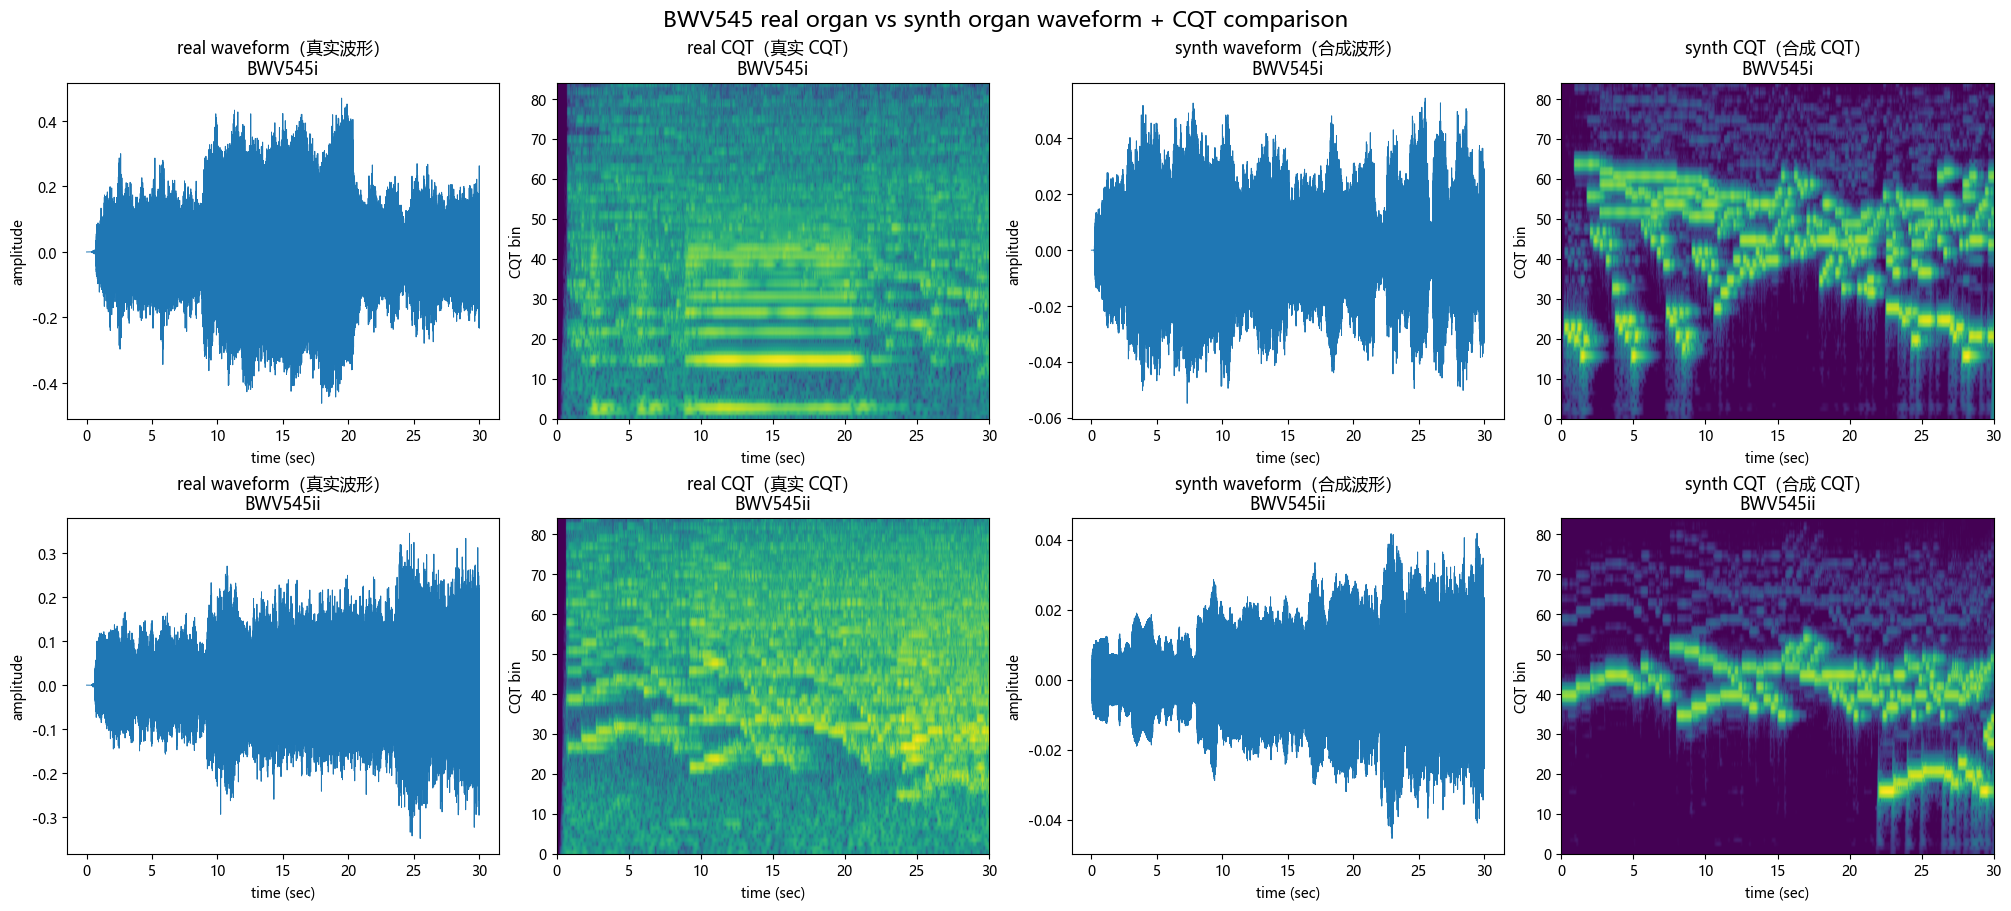

saved: D:\organ-amt-generalization\data\processed\ex01_data_check\BWV545_real_vs_synth_check\figures\BWV545_real_vs_synth_cqt_compare.png


In [7]:
# =========================
# 6. 画 real / synth waveform + CQT 对比图
# =========================

def resolve_audio_path(path_value):
    p = Path(str(path_value))
    if p.is_absolute():
        return p
    return PROJECT_ROOT / p

def load_audio_segment(audio_path, start_sec=0.0, duration_sec=30.0, target_sr=44100):
    audio_path = resolve_audio_path(audio_path)
    if not audio_path.exists():
        raise FileNotFoundError(f"audio not found: {audio_path}")

    y, sr = librosa.load(
        str(audio_path),
        sr=target_sr,
        mono=True,
        offset=start_sec,
        duration=duration_sec,
    )

    if len(y) == 0:
        raise ValueError(f"empty audio segment: {audio_path}")

    return y, sr

def compute_cqt_db(y, sr):
    cqt = librosa.cqt(
        y=y,
        sr=sr,
        hop_length=CQT_HOP_LENGTH,
        fmin=CQT_FMIN,
        n_bins=CQT_N_BINS,
        bins_per_octave=CQT_BINS_PER_OCTAVE,
    )
    return librosa.amplitude_to_db(np.abs(cqt), ref=np.max)

def plot_waveform(ax, y, sr, start_sec, title):
    t = np.arange(len(y)) / sr + start_sec
    ax.plot(t, y, linewidth=0.7)
    ax.set_title(title)
    ax.set_xlabel("time (sec)")
    ax.set_ylabel("amplitude")

def plot_cqt(ax, cqt_db, start_sec, duration_sec, title):
    extent = [start_sec, start_sec + duration_sec, 0, CQT_N_BINS]
    im = ax.imshow(cqt_db, origin="lower", aspect="auto", extent=extent)
    ax.set_title(title)
    ax.set_xlabel("time (sec)")
    ax.set_ylabel("CQT bin")
    return im

# 为了同曲目对比，按文件名 stem 尝试配对；如果配不上，则按顺序配对
real_table = real_compare_df.copy()
synth_table = synth_df.copy()

real_table["key"] = real_table["sample_id"].astype(str).str.lower()
synth_table["key"] = synth_table["sample_id"].astype(str).str.lower()

pairs = []
used_synth = set()

for _, r in real_table.iterrows():
    # 精确匹配
    candidates = synth_table[synth_table["key"] == r["key"]]

    # 如果精确匹配不到，尝试包含关系
    if len(candidates) == 0:
        candidates = synth_table[
            synth_table["key"].apply(lambda s: s in r["key"] or r["key"] in s)
        ]

    if len(candidates) > 0:
        s = candidates.iloc[0]
        used_synth.add(s["sample_id"])
        pairs.append({
            "real_sample_id": r["sample_id"],
            "real_audio_path": r["audio_path"],
            "synth_sample_id": s["sample_id"],
            "synth_audio_path": s["audio_path"],
            "pair_type": "name_match",
        })

# 如果没有配上，就按顺序配对
if len(pairs) == 0:
    n = min(len(real_table), len(synth_table))
    for i in range(n):
        r = real_table.iloc[i]
        s = synth_table.iloc[i]
        pairs.append({
            "real_sample_id": r["sample_id"],
            "real_audio_path": r["audio_path"],
            "synth_sample_id": s["sample_id"],
            "synth_audio_path": s["audio_path"],
            "pair_type": "order_match",
        })

pair_df = pd.DataFrame(pairs)
pair_df.to_csv(BWV545_OUT_DIR / "BWV545_real_vs_synth_cqt_pairs.csv", index=False, encoding="utf-8-sig")

print("CQT pairs:")
display(pair_df)

n = len(pair_df)
if n == 0:
    raise ValueError("没有可对比的 real/synth pair。")

fig, axes = plt.subplots(
    n,
    4,
    figsize=(20, 4.5 * n),
    constrained_layout=True,
)

if n == 1:
    axes = np.array([axes])

for i, row in pair_df.iterrows():
    real_id = row["real_sample_id"]
    synth_id = row["synth_sample_id"]

    y_real, sr_real = load_audio_segment(row["real_audio_path"], SEGMENT_START_SEC, SEGMENT_DURATION_SEC, TARGET_SR)
    y_synth, sr_synth = load_audio_segment(row["synth_audio_path"], SEGMENT_START_SEC, SEGMENT_DURATION_SEC, TARGET_SR)

    cqt_real = compute_cqt_db(y_real, sr_real)
    cqt_synth = compute_cqt_db(y_synth, sr_synth)

    plot_waveform(
        axes[i, 0],
        y_real,
        sr_real,
        SEGMENT_START_SEC,
        f"real waveform（真实波形）\n{real_id}",
    )

    plot_cqt(
        axes[i, 1],
        cqt_real,
        SEGMENT_START_SEC,
        SEGMENT_DURATION_SEC,
        f"real CQT（真实 CQT）\n{real_id}",
    )

    plot_waveform(
        axes[i, 2],
        y_synth,
        sr_synth,
        SEGMENT_START_SEC,
        f"synth waveform（合成波形）\n{synth_id}",
    )

    plot_cqt(
        axes[i, 3],
        cqt_synth,
        SEGMENT_START_SEC,
        SEGMENT_DURATION_SEC,
        f"synth CQT（合成 CQT）\n{synth_id}",
    )

fig.suptitle("BWV545 real organ vs synth organ waveform + CQT comparison", fontsize=16)
fig.savefig(CQT_COMPARE_FIG_PATH, dpi=150)
plt.show()

print("saved:", CQT_COMPARE_FIG_PATH)


,pair_id,real_sample_id,real_audio_path,synth_sample_id,synth_audio_path,vst_sample_id,vst_audio_path
0,0,BWV545i,D:\organ-amt-generalization\data\processed\ex0...,BWV545i,data/processed/ex01_data_check/BWV545_real_vs_...,BWV545i__sine_player,D:\organ-amt-generalization\data\rendered\BWV ...
1,1,BWV545ii,D:\organ-amt-generalization\data\processed\ex0...,BWV545ii,data/processed/ex01_data_check/BWV545_real_vs_...,BWV545ii__sine_player,D:\organ-amt-generalization\data\rendered\BWV ...


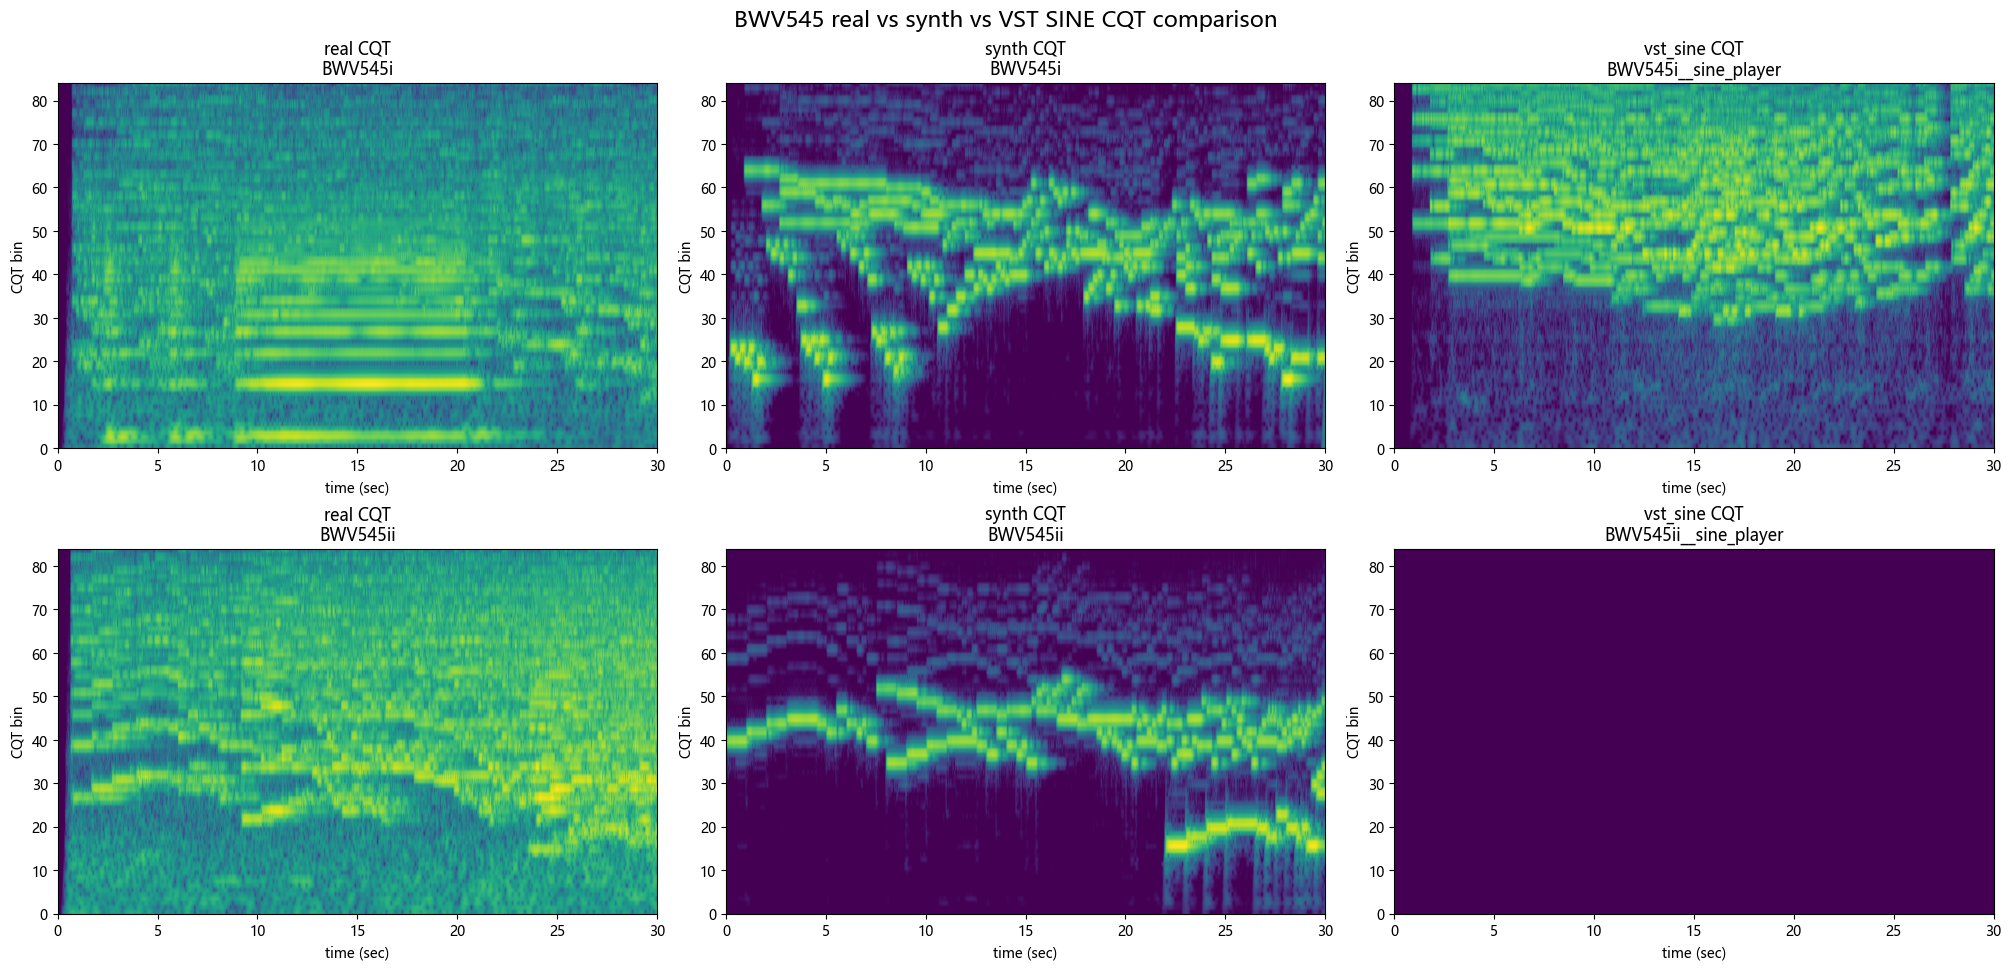

saved: D:\organ-amt-generalization\data\processed\ex01_data_check\BWV545_real_vs_synth_check\figures\BWV545_real_synth_vst_cqt_compare.png


In [8]:
# =========================
# 6.6 real / synth / vst_sine 三类 CQT 对比子图
# =========================

CQT_THREE_DOMAIN_FIG_PATH = FIGURE_DIR / "BWV545_real_synth_vst_cqt_compare.png"

real_table = real_compare_df.copy().reset_index(drop=True)
synth_table = synth_df.copy().reset_index(drop=True)
vst_table = rendered_df.copy().reset_index(drop=True)

n = min(len(real_table), len(synth_table), len(vst_table))

if n == 0:
    raise ValueError("real / synth / vst_sine 至少有一类为空，无法三类对比。")

three_domain_pairs = []

for i in range(n):
    r = real_table.iloc[i]
    s = synth_table.iloc[i]
    v = vst_table.iloc[i]

    three_domain_pairs.append({
        "pair_id": i,
        "real_sample_id": r["sample_id"],
        "real_audio_path": r["audio_path"],
        "synth_sample_id": s["sample_id"],
        "synth_audio_path": s["audio_path"],
        "vst_sample_id": v["sample_id"],
        "vst_audio_path": v["audio_path"],
    })

three_pair_df = pd.DataFrame(three_domain_pairs)
three_pair_df.to_csv(
    BWV545_OUT_DIR / "BWV545_real_synth_vst_cqt_pairs.csv",
    index=False,
    encoding="utf-8-sig",
)

display(three_pair_df)

fig, axes = plt.subplots(
    n,
    3,
    figsize=(20, 4.8 * n),
    constrained_layout=True,
)

if n == 1:
    axes = np.array([axes])

for i, row in three_pair_df.iterrows():
    items = [
        ("real", row["real_sample_id"], row["real_audio_path"]),
        ("synth", row["synth_sample_id"], row["synth_audio_path"]),
        ("vst_sine", row["vst_sample_id"], row["vst_audio_path"]),
    ]

    for j, (domain, sample_id, audio_path) in enumerate(items):
        y, sr = load_audio_segment(
            audio_path=audio_path,
            start_sec=SEGMENT_START_SEC,
            duration_sec=SEGMENT_DURATION_SEC,
            target_sr=TARGET_SR,
        )

        cqt_db = compute_cqt_db(y, sr)

        plot_cqt(
            axes[i, j],
            cqt_db,
            SEGMENT_START_SEC,
            SEGMENT_DURATION_SEC,
            f"{domain} CQT\n{sample_id}",
        )

fig.suptitle("BWV545 real vs synth vs VST SINE CQT comparison", fontsize=16)
fig.savefig(CQT_THREE_DOMAIN_FIG_PATH, dpi=150)
plt.show()

print("saved:", CQT_THREE_DOMAIN_FIG_PATH)

In [9]:
# =========================
# 7. 提取音频特征
# =========================

MFCC_N = 13

def extract_audio_features(audio_path, target_sr=44100, duration_sec=30.0):
    audio_path = resolve_audio_path(audio_path)

    if not audio_path.exists():
        raise FileNotFoundError(f"audio file not found: {audio_path}")

    info = sf.info(str(audio_path))

    y, sr = librosa.load(
        str(audio_path),
        sr=target_sr,
        mono=True,
        duration=duration_sec,
    )

    if len(y) == 0:
        raise ValueError(f"empty audio: {audio_path}")

    rms = librosa.feature.rms(y=y)[0]
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)[0]
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)[0]
    flatness = librosa.feature.spectral_flatness(y=y)[0]
    zcr = librosa.feature.zero_crossing_rate(y=y)[0]
    onset_env = librosa.onset.onset_strength(y=y, sr=sr)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=MFCC_N)

    abs_y = np.abs(y)

    result = {
        "resolved_audio_path": str(audio_path),
        "file_duration_sec": float(info.duration),
        "file_sample_rate": int(info.samplerate),
        "file_channels": int(info.channels),
        "feature_duration_sec": float(len(y) / sr),
        "max_amplitude": float(np.max(abs_y)),
        "rms_mean": float(np.mean(rms)),
        "rms_std": float(np.std(rms)),
        "rms_p95": float(np.percentile(rms, 95)),
        "dynamic_range": float(np.percentile(abs_y, 95) - np.percentile(abs_y, 5)),
        "centroid_mean": float(np.mean(centroid)),
        "centroid_std": float(np.std(centroid)),
        "bandwidth_mean": float(np.mean(bandwidth)),
        "bandwidth_std": float(np.std(bandwidth)),
        "rolloff_mean": float(np.mean(rolloff)),
        "rolloff_std": float(np.std(rolloff)),
        "flatness_mean": float(np.mean(flatness)),
        "flatness_std": float(np.std(flatness)),
        "zcr_mean": float(np.mean(zcr)),
        "zcr_std": float(np.std(zcr)),
        "onset_strength_mean": float(np.mean(onset_env)),
        "onset_strength_std": float(np.std(onset_env)),
    }

    for i in range(MFCC_N):
        result[f"mfcc_{i + 1}_mean"] = float(np.mean(mfcc[i]))
        result[f"mfcc_{i + 1}_std"] = float(np.std(mfcc[i]))

    return result

feature_rows = []

for idx, row in compare_df.iterrows():
    try:
        feat = extract_audio_features(
            audio_path=row["audio_path"],
            target_sr=TARGET_SR,
            duration_sec=FEATURE_DURATION_SEC,
        )
        feat["sample_id"] = row["sample_id"]
        feat["domain"] = row["domain"]
        feat["audio_path"] = row["audio_path"]
        feat["error"] = None
    except Exception as e:
        feat = {
            "sample_id": row["sample_id"],
            "domain": row["domain"],
            "audio_path": row["audio_path"],
            "error": repr(e),
        }

    feature_rows.append(feat)
    print(f"processed {idx + 1}/{len(compare_df)}: {row['domain']} | {row['sample_id']}")

feat_df = pd.DataFrame(feature_rows)
feat_df.to_csv(FEATURE_TABLE_PATH, index=False, encoding="utf-8-sig")

print("feat_df shape:", feat_df.shape)
print("columns:", feat_df.columns.tolist())
display(feat_df.head())
display(feat_df["domain"].value_counts())
display(feat_df["error"].notna().value_counts())

if feat_df["error"].notna().any():
    display(feat_df[feat_df["error"].notna()][["sample_id", "domain", "audio_path", "error"]])

print("saved:", FEATURE_TABLE_PATH)


processed 1/4: real | BWV545i
processed 2/4: real | BWV545ii
processed 3/4: synth | BWV545i
processed 4/4: synth | BWV545ii
feat_df shape: (4, 52)
columns: ['resolved_audio_path', 'file_duration_sec', 'file_sample_rate', 'file_channels', 'feature_duration_sec', 'max_amplitude', 'rms_mean', 'rms_std', 'rms_p95', 'dynamic_range', 'centroid_mean', 'centroid_std', 'bandwidth_mean', 'bandwidth_std', 'rolloff_mean', 'rolloff_std', 'flatness_mean', 'flatness_std', 'zcr_mean', 'zcr_std', 'onset_strength_mean', 'onset_strength_std', 'mfcc_1_mean', 'mfcc_1_std', 'mfcc_2_mean', 'mfcc_2_std', 'mfcc_3_mean', 'mfcc_3_std', 'mfcc_4_mean', 'mfcc_4_std', 'mfcc_5_mean', 'mfcc_5_std', 'mfcc_6_mean', 'mfcc_6_std', 'mfcc_7_mean', 'mfcc_7_std', 'mfcc_8_mean', 'mfcc_8_std', 'mfcc_9_mean', 'mfcc_9_std', 'mfcc_10_mean', 'mfcc_10_std', 'mfcc_11_mean', 'mfcc_11_std', 'mfcc_12_mean', 'mfcc_12_std', 'mfcc_13_mean', 'mfcc_13_std', 'sample_id', 'domain', 'audio_path', 'error']


,resolved_audio_path,file_duration_sec,file_sample_rate,file_channels,feature_duration_sec,max_amplitude,rms_mean,rms_std,rms_p95,dynamic_range,...,mfcc_11_mean,mfcc_11_std,mfcc_12_mean,mfcc_12_std,mfcc_13_mean,mfcc_13_std,sample_id,domain,audio_path,error
0,D:\organ-amt-generalization\data\processed\ex0...,113.404807,44100,1,30.0,0.469910,0.089626,0.043031,0.156980,0.213776,...,0.620757,6.293244,3.217425,6.463446,1.324821,7.126302,BWV545i,real,D:\organ-amt-generalization\data\processed\ex0...,None
1,D:\organ-amt-generalization\data\processed\ex0...,225.092789,44100,1,30.0,0.347900,0.056878,0.019827,0.092275,0.120972,...,-2.896052,6.659616,-4.159638,5.680393,-0.072227,5.988384,BWV545ii,real,D:\organ-amt-generalization\data\processed\ex0...,None
2,D:\organ-amt-generalization\data\processed\ex0...,117.516190,44100,2,30.0,0.054901,0.012582,0.003533,0.017984,0.025284,...,-5.109587,25.889618,-4.340393,23.946871,-4.960937,20.364784,BWV545i,synth,data/processed/ex01_data_check/BWV545_real_vs_...,None
3,D:\organ-amt-generalization\data\processed\ex0...,231.537778,44100,2,30.0,0.045395,0.009950,0.003292,0.015242,0.019867,...,-25.521164,15.183317,-27.969112,12.330915,-26.953028,12.881853,BWV545ii,synth,data/processed/ex01_data_check/BWV545_real_vs_...,None


domain
real     2
synth    2
Name: count, dtype: int64

error
False    4
Name: count, dtype: int64

saved: D:\organ-amt-generalization\data\processed\ex01_data_check\BWV545_real_vs_synth_check\BWV545_real_vs_synth_feature_table.csv


numeric_cols: ['file_duration_sec', 'file_sample_rate', 'file_channels', 'feature_duration_sec', 'max_amplitude', 'rms_mean', 'rms_std', 'rms_p95', 'dynamic_range', 'centroid_mean', 'centroid_std', 'bandwidth_mean', 'bandwidth_std', 'rolloff_mean', 'rolloff_std', 'flatness_mean', 'flatness_std', 'zcr_mean', 'zcr_std', 'onset_strength_mean', 'onset_strength_std', 'mfcc_1_mean', 'mfcc_1_std', 'mfcc_2_mean', 'mfcc_2_std', 'mfcc_3_mean', 'mfcc_3_std', 'mfcc_4_mean', 'mfcc_4_std', 'mfcc_5_mean', 'mfcc_5_std', 'mfcc_6_mean', 'mfcc_6_std', 'mfcc_7_mean', 'mfcc_7_std', 'mfcc_8_mean', 'mfcc_8_std', 'mfcc_9_mean', 'mfcc_9_std', 'mfcc_10_mean', 'mfcc_10_std', 'mfcc_11_mean', 'mfcc_11_std', 'mfcc_12_mean', 'mfcc_12_std', 'mfcc_13_mean', 'mfcc_13_std']
feature summary:


,domain,feature,count,mean,std,median,min,max
0,real,file_duration_sec,2,169.248798,78.975329,169.248798,113.404807,225.092789
1,real,file_sample_rate,2,44100.000000,0.000000,44100.000000,44100.000000,44100.000000
2,real,file_channels,2,1.000000,0.000000,1.000000,1.000000,1.000000
3,real,feature_duration_sec,2,30.000000,0.000000,30.000000,30.000000,30.000000
4,real,max_amplitude,2,0.408905,0.086274,0.408905,0.347900,0.469910
5,real,rms_mean,2,0.073252,0.023156,0.073252,0.056878,0.089626
6,real,rms_std,2,0.031429,0.016408,0.031429,0.019827,0.043031
7,real,rms_p95,2,0.124627,0.045754,0.124627,0.092275,0.156980
8,real,dynamic_range,2,0.167374,0.065622,0.167374,0.120972,0.213776
9,real,centroid_mean,2,1249.948054,192.521464,1249.948054,1113.814822,1386.081287


saved: D:\organ-amt-generalization\data\processed\ex01_data_check\BWV545_real_vs_synth_check\BWV545_real_vs_synth_feature_summary.csv
feature distance:


,feature,real_count,synth_count,real_mean,synth_mean,mean_diff_real_minus_synth,ks_statistic,ks_pvalue,wasserstein_distance
13,rolloff_mean,2,2,2298.323602,581.392318,1716.931285,1.0,0.333333,1716.931285
9,centroid_mean,2,2,1249.948054,599.773084,650.174971,1.0,0.333333,650.174971
21,mfcc_1_mean,2,2,-273.540268,-689.084167,415.543900,1.0,0.333333,415.543900
14,rolloff_std,2,2,845.421134,548.803696,296.617438,0.5,1.000000,377.423495
11,bandwidth_mean,2,2,1601.406569,1477.652387,123.754182,1.0,0.333333,123.754182
25,mfcc_3_mean,2,2,-41.871614,62.655828,-104.527443,1.0,0.333333,104.527443
10,centroid_std,2,2,351.472735,252.157968,99.314767,0.5,1.000000,99.314767
12,bandwidth_std,2,2,471.787737,393.694435,78.093302,1.0,0.333333,78.093302
23,mfcc_2_mean,2,2,223.565689,147.050213,76.515476,1.0,0.333333,76.515476
22,mfcc_1_std,2,2,58.565577,32.298978,26.266599,1.0,0.333333,26.266599


saved: D:\organ-amt-generalization\data\processed\ex01_data_check\BWV545_real_vs_synth_check\BWV545_real_vs_synth_feature_distance.csv


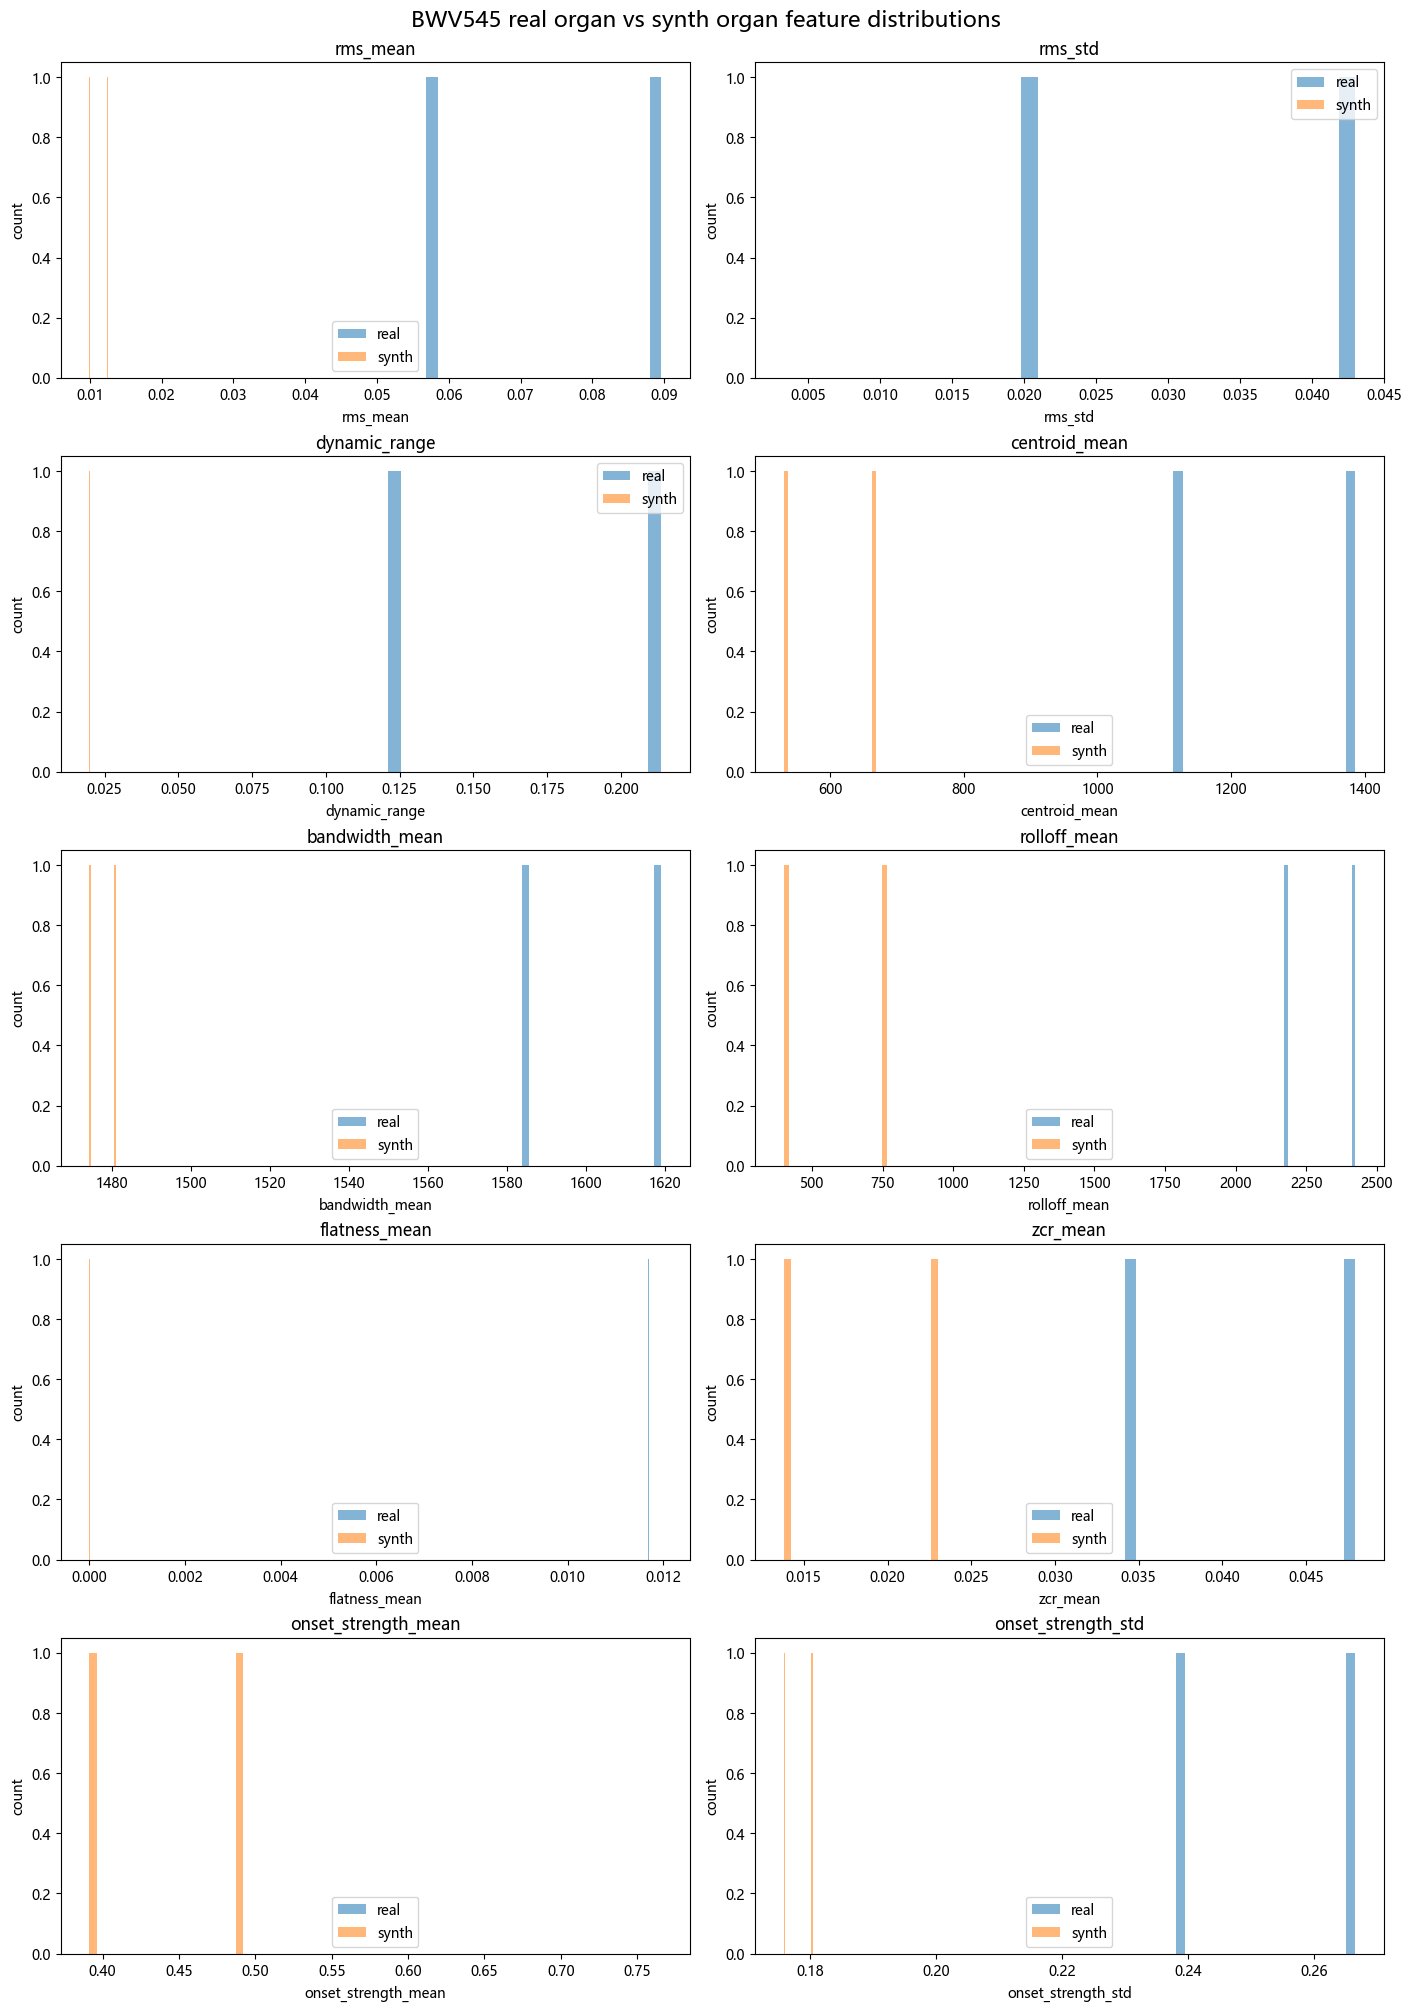

saved: D:\organ-amt-generalization\data\processed\ex01_data_check\BWV545_real_vs_synth_check\figures\BWV545_real_vs_synth_feature_histograms.png


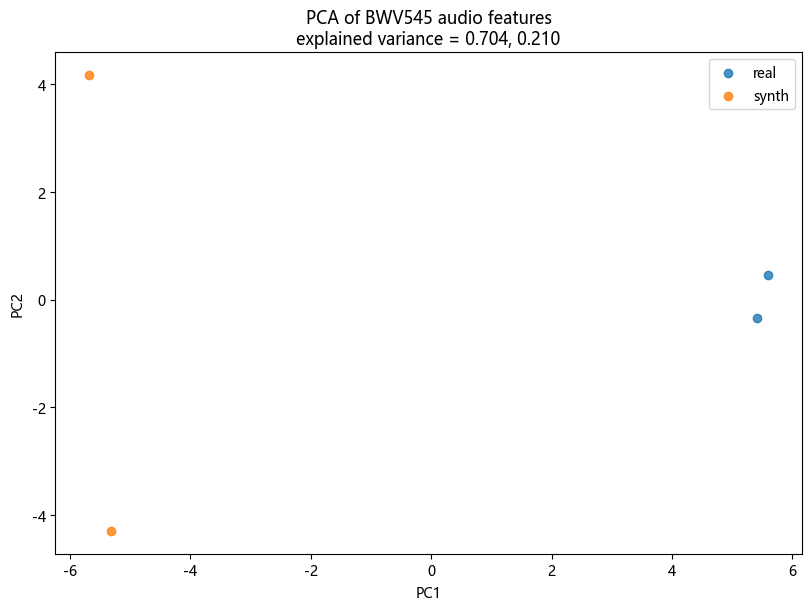

saved: D:\organ-amt-generalization\data\processed\ex01_data_check\BWV545_real_vs_synth_check\figures\BWV545_real_vs_synth_pca.png


In [10]:
# =========================
# 8. 特征分布、距离、PCA
# =========================

if "domain" not in feat_df.columns:
    raise ValueError("feat_df 中没有 domain 列。")

exclude_cols = {
    "sample_id",
    "domain",
    "audio_path",
    "resolved_audio_path",
    "error",
}

numeric_cols = [
    c for c in feat_df.columns
    if c not in exclude_cols and pd.api.types.is_numeric_dtype(feat_df[c])
]

print("numeric_cols:", numeric_cols)

if len(numeric_cols) == 0:
    raise ValueError("numeric_cols 为空。说明特征提取没有成功生成数值特征。请检查 feat_df['error']。")

# 汇总
summary_rows = []
for domain, g in feat_df.groupby("domain"):
    for col in numeric_cols:
        values = g[col].dropna()
        if len(values) == 0:
            continue
        summary_rows.append({
            "domain": domain,
            "feature": col,
            "count": int(len(values)),
            "mean": float(values.mean()),
            "std": float(values.std()) if len(values) > 1 else 0.0,
            "median": float(values.median()),
            "min": float(values.min()),
            "max": float(values.max()),
        })

feature_summary = pd.DataFrame(summary_rows)
feature_summary.to_csv(FEATURE_SUMMARY_PATH, index=False, encoding="utf-8-sig")

print("feature summary:")
display(feature_summary.head(30))
print("saved:", FEATURE_SUMMARY_PATH)

# 分布距离
distance_rows = []
for col in numeric_cols:
    real_values = feat_df.loc[feat_df["domain"] == "real", col].dropna()
    synth_values = feat_df.loc[feat_df["domain"] == "synth", col].dropna()

    if len(real_values) == 0 or len(synth_values) == 0:
        continue

    ks_result = ks_2samp(real_values, synth_values)
    wd = wasserstein_distance(real_values, synth_values)

    distance_rows.append({
        "feature": col,
        "real_count": int(len(real_values)),
        "synth_count": int(len(synth_values)),
        "real_mean": float(real_values.mean()),
        "synth_mean": float(synth_values.mean()),
        "mean_diff_real_minus_synth": float(real_values.mean() - synth_values.mean()),
        "ks_statistic": float(ks_result.statistic),
        "ks_pvalue": float(ks_result.pvalue),
        "wasserstein_distance": float(wd),
    })

distance_cols = [
    "feature",
    "real_count",
    "synth_count",
    "real_mean",
    "synth_mean",
    "mean_diff_real_minus_synth",
    "ks_statistic",
    "ks_pvalue",
    "wasserstein_distance",
]

feature_distance = pd.DataFrame(distance_rows, columns=distance_cols)

if len(feature_distance) > 0:
    feature_distance = feature_distance.sort_values("wasserstein_distance", ascending=False)

feature_distance.to_csv(FEATURE_DISTANCE_PATH, index=False, encoding="utf-8-sig")

print("feature distance:")
display(feature_distance.head(30))
print("saved:", FEATURE_DISTANCE_PATH)

# 画图
plot_cols = [
    "rms_mean",
    "rms_std",
    "dynamic_range",
    "centroid_mean",
    "bandwidth_mean",
    "rolloff_mean",
    "flatness_mean",
    "zcr_mean",
    "onset_strength_mean",
    "onset_strength_std",
]

plot_cols = [c for c in plot_cols if c in feat_df.columns]

n_cols = 2
n_rows = int(np.ceil(len(plot_cols) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, 4 * n_rows),
    constrained_layout=True,
)

axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, plot_cols):
    for domain in ["real", "synth"]:
        values = feat_df.loc[feat_df["domain"] == domain, col].dropna()
        ax.hist(values, bins=20, alpha=0.55, label=domain)

    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("count")
    ax.legend()

for ax in axes[len(plot_cols):]:
    ax.axis("off")

fig.suptitle("BWV545 real organ vs synth organ feature distributions", fontsize=16)
fig.savefig(FEATURE_HIST_FIG_PATH, dpi=150)
plt.show()

print("saved:", FEATURE_HIST_FIG_PATH)

# PCA
pca_feature_cols = [
    c for c in numeric_cols
    if c not in {
        "file_duration_sec",
        "file_sample_rate",
        "file_channels",
        "feature_duration_sec",
    }
]

pca_df = feat_df[["sample_id", "domain"] + pca_feature_cols].copy()
pca_df = pca_df.dropna()

if len(pca_df) >= 3 and pca_df["domain"].nunique() >= 2 and len(pca_feature_cols) >= 2:
    X = pca_df[pca_feature_cols].values
    X_scaled = StandardScaler().fit_transform(X)

    pca = PCA(n_components=2, random_state=42)
    Z = pca.fit_transform(X_scaled)

    pca_df["pc1"] = Z[:, 0]
    pca_df["pc2"] = Z[:, 1]

    fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)

    for domain in ["real", "synth"]:
        sub = pca_df[pca_df["domain"] == domain]
        ax.scatter(sub["pc1"], sub["pc2"], label=domain, alpha=0.8)

    ax.set_title(
        "PCA of BWV545 audio features\n"
        f"explained variance = {pca.explained_variance_ratio_[0]:.3f}, "
        f"{pca.explained_variance_ratio_[1]:.3f}"
    )
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend()

    fig.savefig(PCA_FIG_PATH, dpi=150)
    plt.show()

    print("saved:", PCA_FIG_PATH)
else:
    print("PCA skipped: 样本数不足、特征不足或类别不足。")


In [11]:
# =========================
# 9. 最终输出路径汇总
# =========================

print("Finished BWV545 real vs synth check.")
print("\nOutput directory:")
print(BWV545_OUT_DIR)

print("\nTables:")
for p in [
    REAL_AUDIO_TABLE_PATH,
    SYNTH_METADATA_PATH,
    COMPARE_SAMPLES_PATH,
    FEATURE_TABLE_PATH,
    FEATURE_SUMMARY_PATH,
    FEATURE_DISTANCE_PATH,
]:
    print(p, "exists:", Path(p).exists())

print("\nFigures:")
for p in [
    CQT_COMPARE_FIG_PATH,
    FEATURE_HIST_FIG_PATH,
    PCA_FIG_PATH,
]:
    print(p, "exists:", Path(p).exists())


Finished BWV545 real vs synth check.

Output directory:
D:\organ-amt-generalization\data\processed\ex01_data_check\BWV545_real_vs_synth_check

Tables:
D:\organ-amt-generalization\data\processed\ex01_data_check\BWV545_real_vs_synth_check\BWV545_real_audio_files.csv exists: True
D:\organ-amt-generalization\data\processed\ex01_data_check\BWV545_real_vs_synth_check\BWV545_synth_metadata.csv exists: True
D:\organ-amt-generalization\data\processed\ex01_data_check\BWV545_real_vs_synth_check\BWV545_real_vs_synth_samples.csv exists: True
D:\organ-amt-generalization\data\processed\ex01_data_check\BWV545_real_vs_synth_check\BWV545_real_vs_synth_feature_table.csv exists: True
D:\organ-amt-generalization\data\processed\ex01_data_check\BWV545_real_vs_synth_check\BWV545_real_vs_synth_feature_summary.csv exists: True
D:\organ-amt-generalization\data\processed\ex01_data_check\BWV545_real_vs_synth_check\BWV545_real_vs_synth_feature_distance.csv exists: True

Figures:
D:\organ-amt-generalization\data\pro

In [12]:
from pathlib import Path
import importlib.util
import sys

SCRIPT_PATH = Path(r"D:\organ-amt-generalization\scripts\render_midi_sine.py")

print("script exists:", SCRIPT_PATH.exists())
print("script path:", SCRIPT_PATH)

if not SCRIPT_PATH.exists():
    raise FileNotFoundError(f"脚本不存在: {SCRIPT_PATH}")

spec = importlib.util.spec_from_file_location(
    "render_midi_sine_module",
    SCRIPT_PATH
)

render_midi_sine_module = importlib.util.module_from_spec(spec)
sys.modules["render_midi_sine_module"] = render_midi_sine_module
spec.loader.exec_module(render_midi_sine_module)

render_midi_to_wav = render_midi_sine_module.render_midi_to_wav

print("load ok")

script exists: True
script path: D:\organ-amt-generalization\scripts\render_midi_sine.py
load ok


In [13]:
from pathlib import Path
import numpy as np
import pandas as pd
import soundfile as sf

# =========================
# 检查 rendered/BWV 545 下的 wav
# =========================

WAV_DIR = Path(r"D:\organ-amt-generalization\data\rendered\BWV 545")

print("WAV_DIR:", WAV_DIR)
print("exists:", WAV_DIR.exists())
print("is_dir:", WAV_DIR.is_dir())

if not WAV_DIR.exists():
    raise FileNotFoundError(f"文件夹不存在: {WAV_DIR}")

wav_files = sorted(WAV_DIR.rglob("*.wav"))

print("wav count:", len(wav_files))
for p in wav_files:
    print(" -", p)

if len(wav_files) == 0:
    raise FileNotFoundError(f"没有找到 wav 文件: {WAV_DIR}")

# 你 CQT 图里通常用前 30 秒
SEGMENT_START_SEC = 0.0
SEGMENT_DURATION_SEC = 30.0

rows = []

for wav_path in wav_files:
    audio, sr = sf.read(wav_path, always_2d=True)

    duration_sec = len(audio) / sr

    # 整首音频
    peak_abs = float(np.max(np.abs(audio))) if audio.size > 0 else 0.0
    rms = float(np.sqrt(np.mean(audio ** 2))) if audio.size > 0 else 0.0
    nonzero_ratio = float(np.mean(np.abs(audio) > 1e-8)) if audio.size > 0 else 0.0

    # 前 30 秒片段
    start_sample = int(SEGMENT_START_SEC * sr)
    end_sample = int((SEGMENT_START_SEC + SEGMENT_DURATION_SEC) * sr)
    segment = audio[start_sample:end_sample]

    segment_peak_abs = float(np.max(np.abs(segment))) if segment.size > 0 else 0.0
    segment_rms = float(np.sqrt(np.mean(segment ** 2))) if segment.size > 0 else 0.0

    rows.append({
        "file": wav_path.name,
        "path": str(wav_path),
        "sample_rate": sr,
        "channels": audio.shape[1],
        "duration_sec": duration_sec,

        "peak_abs": peak_abs,
        "rms": rms,
        "nonzero_ratio": nonzero_ratio,
        "is_silent_full": peak_abs < 1e-8,

        "segment_start_sec": SEGMENT_START_SEC,
        "segment_duration_sec": SEGMENT_DURATION_SEC,
        "segment_peak_abs": segment_peak_abs,
        "segment_rms": segment_rms,
        "is_silent_segment": segment_peak_abs < 1e-8,
    })

df_wav_check = pd.DataFrame(rows)
display(df_wav_check)

WAV_DIR: D:\organ-amt-generalization\data\rendered\BWV 545
exists: True
is_dir: True
wav count: 2
 - D:\organ-amt-generalization\data\rendered\BWV 545\BWV545i__sine_player.wav
 - D:\organ-amt-generalization\data\rendered\BWV 545\BWV545ii__sine_player.wav


,file,path,sample_rate,channels,duration_sec,peak_abs,rms,nonzero_ratio,is_silent_full,segment_start_sec,segment_duration_sec,segment_peak_abs,segment_rms,is_silent_segment
0,BWV545i__sine_player.wav,D:\organ-amt-generalization\data\rendered\BWV ...,44100,1,118.007574,0.046967,0.007404,0.945188,False,0.0,30.0,0.044922,0.007562,False
1,BWV545ii__sine_player.wav,D:\organ-amt-generalization\data\rendered\BWV ...,44100,1,232.026281,0.031006,0.004872,0.846628,False,0.0,30.0,0.000000,0.000000,True


In [14]:
from pathlib import Path
import pandas as pd
import pretty_midi
import numpy as np

MIDI_DIR = Path(r"D:\organ-amt-generalization\data\raw\organ\BWV545\midi")

midi_files = sorted(list(MIDI_DIR.glob("*.mid")) + list(MIDI_DIR.glob("*.midi")))

rows = []

for midi_path in midi_files:
    pm = pretty_midi.PrettyMIDI(str(midi_path))
    
    note_starts = []
    note_ends = []
    note_pitches = []
    
    for inst in pm.instruments:
        if inst.is_drum:
            continue
        
        for note in inst.notes:
            note_starts.append(note.start)
            note_ends.append(note.end)
            note_pitches.append(note.pitch)
    
    if len(note_starts) == 0:
        rows.append({
            "midi_file": midi_path.name,
            "duration_sec": pm.get_end_time(),
            "num_notes": 0,
            "first_note_start_sec": None,
            "last_note_end_sec": None,
            "min_pitch": None,
            "max_pitch": None,
        })
    else:
        rows.append({
            "midi_file": midi_path.name,
            "duration_sec": pm.get_end_time(),
            "num_notes": len(note_starts),
            "first_note_start_sec": float(np.min(note_starts)),
            "last_note_end_sec": float(np.max(note_ends)),
            "min_pitch": int(np.min(note_pitches)),
            "max_pitch": int(np.max(note_pitches)),
        })

df_midi_check = pd.DataFrame(rows)
display(df_midi_check)

,midi_file,duration_sec,num_notes,first_note_start_sec,last_note_end_sec,min_pitch,max_pitch
0,BWV545i.mid,115.007579,1006,0.220588,115.007579,24,84
1,BWV545ii.mid,229.026299,1628,0.000000,229.026299,24,84


In [15]:
from pathlib import Path
import numpy as np
import pandas as pd
import soundfile as sf

WAV_DIR = Path(r"D:\organ-amt-generalization\data\rendered\BWV 545")

wav_files = sorted(WAV_DIR.glob("*.wav"))

rows = []

threshold = 1e-5

for wav_path in wav_files:
    audio, sr = sf.read(wav_path, always_2d=True)
    mono = audio.mean(axis=1)

    abs_mono = np.abs(mono)
    idx = np.where(abs_mono > threshold)[0]

    if len(idx) == 0:
        first_sound_sec = None
        last_sound_sec = None
    else:
        first_sound_sec = idx[0] / sr
        last_sound_sec = idx[-1] / sr

    rows.append({
        "wav_file": wav_path.name,
        "duration_sec": len(mono) / sr,
        "sample_rate": sr,
        "peak_abs": float(np.max(abs_mono)) if mono.size > 0 else 0.0,
        "rms": float(np.sqrt(np.mean(mono ** 2))) if mono.size > 0 else 0.0,
        "first_sound_sec": first_sound_sec,
        "last_sound_sec": last_sound_sec,
        "is_silent": first_sound_sec is None,
    })

df_wav_sound_check = pd.DataFrame(rows)
display(df_wav_sound_check)

,wav_file,duration_sec,sample_rate,peak_abs,rms,first_sound_sec,last_sound_sec,is_silent
0,BWV545i__sine_player.wav,118.007574,44100,0.046967,0.007404,0.893968,113.150816,False
1,BWV545ii__sine_player.wav,232.026281,44100,0.031006,0.004872,30.011723,227.506961,False
